# Setup

In [1]:
!pip install mujoco gymnasium matplotlib imageio numpy

In [ ]:
import os
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    repo = Path("/content/drive/MyDrive/visual-policy-learning")
except ImportError:
    here = Path.cwd().resolve()
    repo = next((p for p in [here, *here.parents] if (p / "pyproject.toml").exists()), here)

os.chdir(repo)
if Path("/content").exists():
    os.environ.setdefault("MUJOCO_GL", "egl")
print("cwd:", os.getcwd())


# State env

Same reach task as `PandaReachEnv`, but obs is a flat state vector (no RGB).

In [4]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import envs.panda_reach_state_env

importlib.reload(envs.panda_reach_state_env)

from envs.panda_reach_state_env import PandaReachStateEnv

In [5]:
env = PandaReachStateEnv(
    render_mode=True,
    image_width=480,
    image_height=480,
    max_steps=200,
    physics_steps=4,
)

obs, info = env.reset()

print("obs shape:", obs.shape)
print("action shape:", env.action_space.shape)
print("frame size:", env.image_width, "x", env.image_height)
print(info)


obs shape: (20,)
action shape: (8,)
frame size: 480 x 480
{'distance': 0.6108806427993472, 'success': False, 'ee_pos': array([ 8.80000000e-02, -4.20950757e-17,  9.26000000e-01]), 'target_pos': array([0.47233293, 0.01231368, 0.45132987])}


# State layout

`[qpos(7), qvel(7), target(3), ee-target(3)]`

In [6]:
arm = env.arm_dofs

qpos = obs[:arm]
qvel = obs[arm:2 * arm]
target = obs[2 * arm:2 * arm + 3]
ee_delta = obs[2 * arm + 3:]

print("qpos:", qpos)
print("qvel:", qvel)
print("target:", target)
print("ee-target:", ee_delta)
print("distance:", np.linalg.norm(ee_delta))

qpos: [0. 0. 0. 0. 0. 0. 0.]
qvel: [0. 0. 0. 0. 0. 0. 0.]
target: [0.47233292 0.01231368 0.4513299 ]
ee-target: [-0.38433293 -0.01231368  0.4746701 ]
distance: 0.6108806


# Random rollout

In [7]:
obs, info = env.reset()

for i in range(50):

    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    print(i, reward, info["distance"])

    if terminated:
        print("SUCCESS")
        break

    if truncated:
        print("TRUNCATED")
        break

0 -0.7643806512364791 0.6975172747380957
1 -0.8016655829015962 0.6989366755146532
2 -0.8294616652385467 0.6998185249486298
3 -0.8235262889105626 0.6996072455674053
4 -0.8189381824309087 0.6978569304747202
5 -0.8588300802468901 0.6941558202537041
6 -0.8386595805835321 0.6895294129163786
7 -0.8004313160336749 0.6851887306645391
8 -0.7562725004675002 0.6804499156310169
9 -0.7629513198094563 0.6757874805484666
10 -0.776651093915435 0.6718108782048333
11 -0.7674194267386982 0.6681278289525837
12 -0.7763531458932903 0.6623776263040084
13 -0.8037879255566721 0.6548760926180277
14 -0.7738520521131742 0.6464011352982985
15 -0.7691445832742181 0.638683800356201
16 -0.7703525594378807 0.6315457540761262
17 -0.7374526745643124 0.625208033208614
18 -0.7090162638461168 0.6186097731061369
19 -0.7091596096958532 0.6129610041340855
20 -0.6989015063884436 0.606622947887522
21 -0.7017250473091627 0.6011588458643558
22 -0.686837653924235 0.594706501856963
23 -0.6908839809798948 0.5882368950501605
24 -0.71

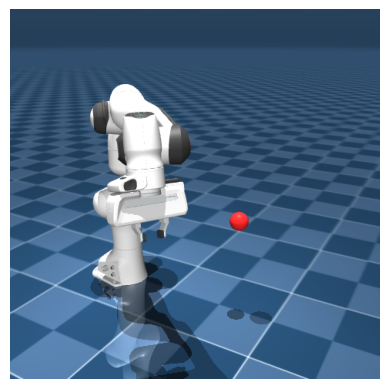

In [8]:
frame = env.render()

plt.imshow(frame)
plt.axis("off")
plt.show()

env.close()